<a href="https://colab.research.google.com/github/umair594/Decode-labs-data-analytics-internship/blob/main/Data_Visualization_and_Business_Storytelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Superstore Sales Analysis: Data Visualization and Business Storytelling**

This project analyzes the Superstore sales dataset from 2015 to 2018 to uncover key business insights through data visualization and storytelling. The objective is to transform raw sales data into meaningful information that supports strategic decision-making. By examining sales performance across years, regions, categories, customer segments, and products, the analysis identifies growth opportunities, top-performing areas, and potential business challenges.

# **STEP 1: Import Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# **STEP 2: Load Dataset**

In [2]:
df = pd.read_csv("train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# **STEP 3: Understand Dataset**

In [3]:
print("Rows and Columns:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
print(df.describe())

Rows and Columns: (9800, 18)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null  

# **STEP 4: Data Cleaning**

In [4]:
# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Create new time columns
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Year-Month"] = df["Order Date"].dt.to_period("M").astype(str)

# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Drop duplicates if any
df = df.drop_duplicates()

df.head()

Duplicate Rows: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Year-Month
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,2017-11
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,2017-11
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2017-06
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,2016-10
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,2016-10


# **STEP 5: Key Business Metrics**

In [5]:
total_sales = df["Sales"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
avg_order_value = total_sales / total_orders

print("Total Sales: $", round(total_sales, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value: $", round(avg_order_value, 2))

Total Sales: $ 2261536.78
Total Orders: 4922
Total Customers: 793
Average Order Value: $ 459.48


# **STEP 6: Sales Trend by Year**

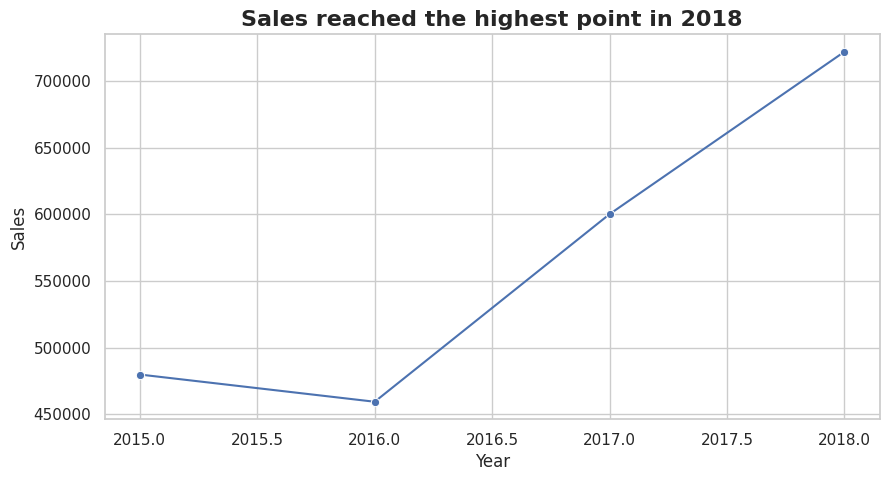

In [6]:
yearly_sales = df.groupby("Year")["Sales"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_sales, x="Year", y="Sales", marker="o")
plt.title("Sales reached the highest point in 2018", fontsize=16, weight="bold")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

# **STEP 7: Monthly Sales Trend**

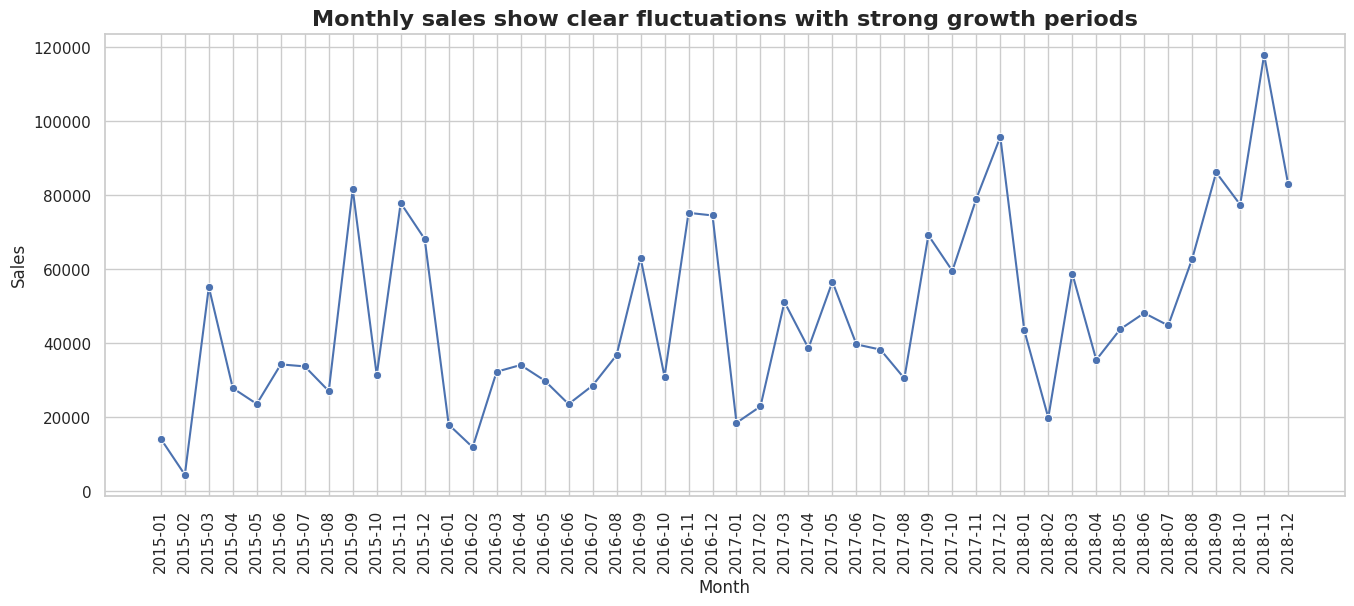

In [7]:
monthly_sales = df.groupby("Year-Month")["Sales"].sum().reset_index()

plt.figure(figsize=(16, 6))
sns.lineplot(data=monthly_sales, x="Year-Month", y="Sales", marker="o")
plt.title("Monthly sales show clear fluctuations with strong growth periods", fontsize=16, weight="bold")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.ticklabel_format(style="plain", axis="y")
plt.show()

# **STEP 8: Sales by Category**

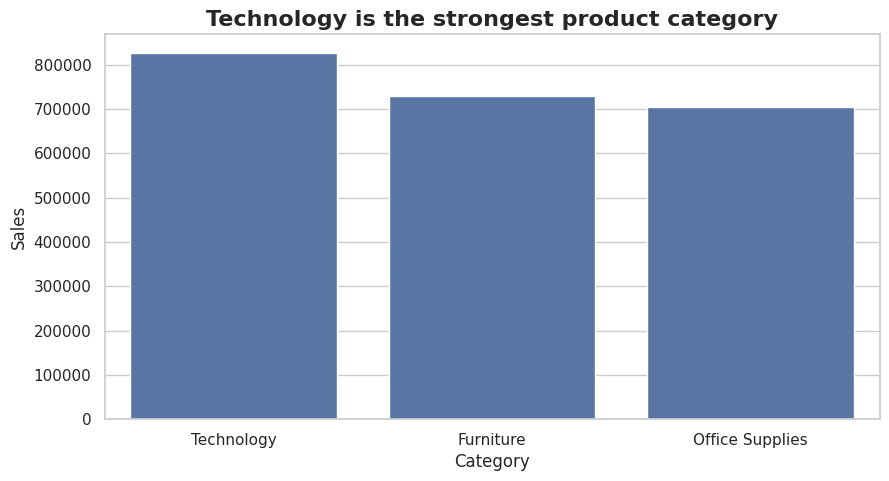

In [8]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=category_sales, x="Category", y="Sales")
plt.title("Technology is the strongest product category", fontsize=16, weight="bold")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

# **STEP 9: Sales by Region**

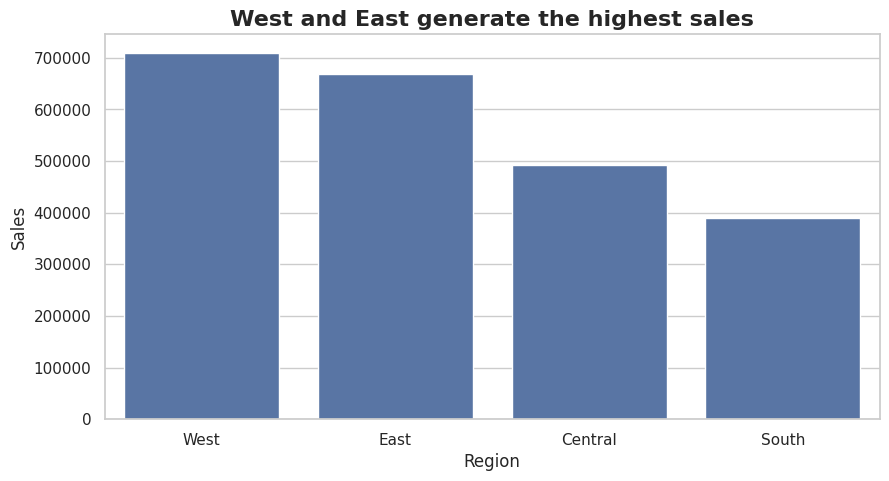

In [9]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=region_sales, x="Region", y="Sales")
plt.title("West and East generate the highest sales", fontsize=16, weight="bold")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

# **STEP 10: Sales by Segment**

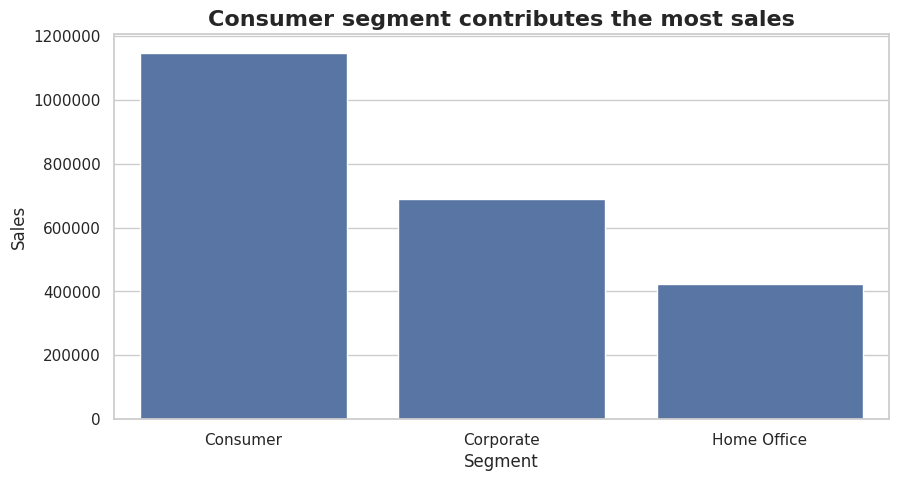

In [10]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=segment_sales, x="Segment", y="Sales")
plt.title("Consumer segment contributes the most sales", fontsize=16, weight="bold")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

# **STEP 11: Top 10 Sub-Categories**

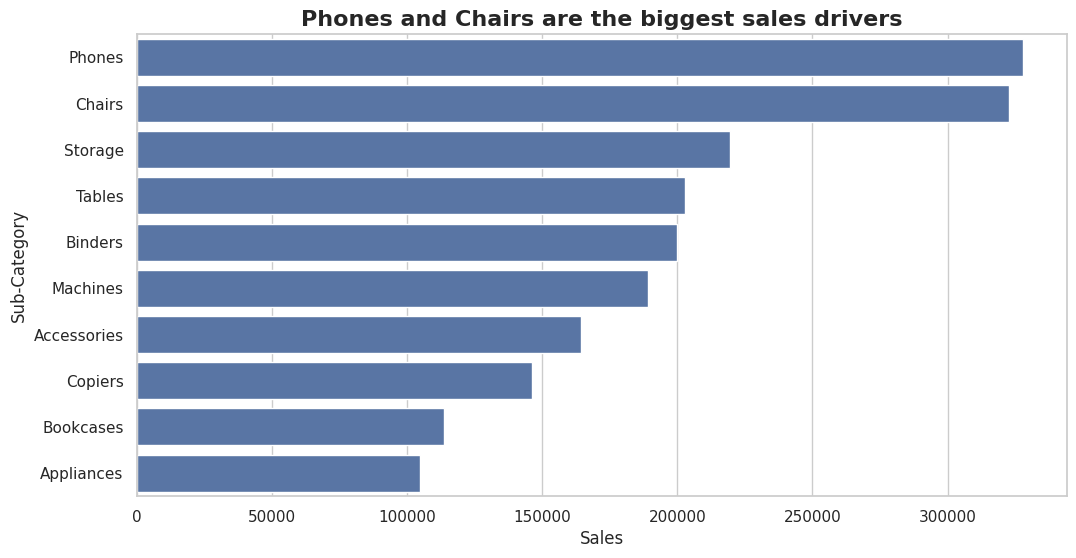

In [11]:
subcat_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=subcat_sales, y="Sub-Category", x="Sales")
plt.title("Phones and Chairs are the biggest sales drivers", fontsize=16, weight="bold")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

# **STEP 12: Top 10 States by Sales**

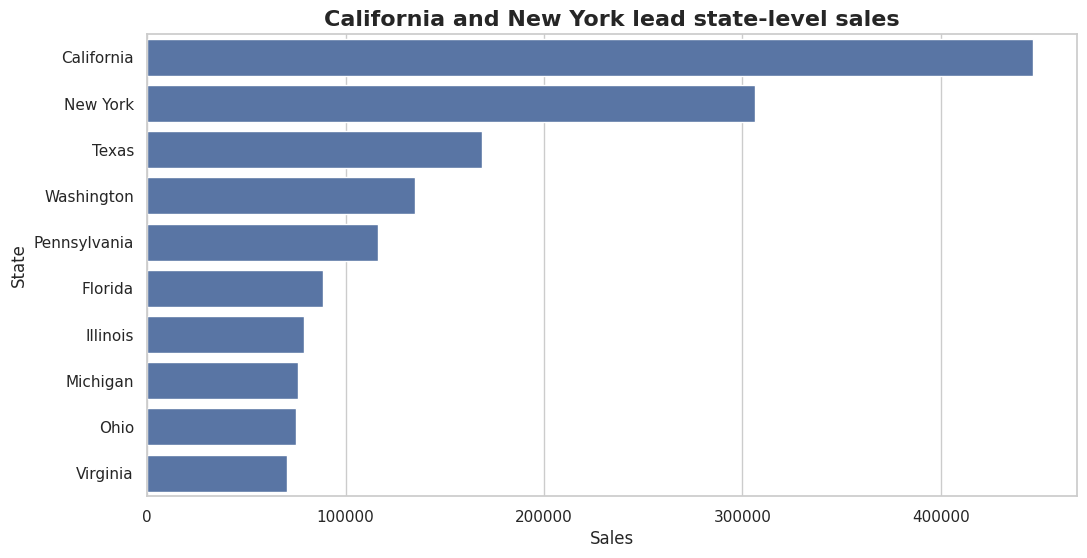

In [12]:
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=state_sales, y="State", x="Sales")
plt.title("California and New York lead state-level sales", fontsize=16, weight="bold")
plt.xlabel("Sales")
plt.ylabel("State")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

# **STEP 13: Top 10 Cities by Sales**

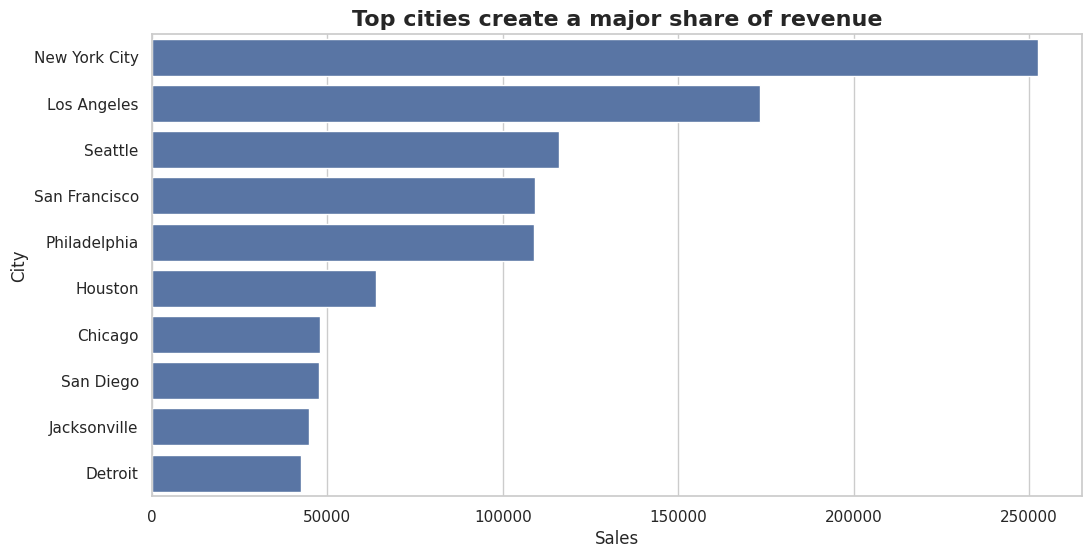

In [13]:
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=city_sales, y="City", x="Sales")
plt.title("Top cities create a major share of revenue", fontsize=16, weight="bold")
plt.xlabel("Sales")
plt.ylabel("City")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

# **STEP 14: Category Sales by Region**

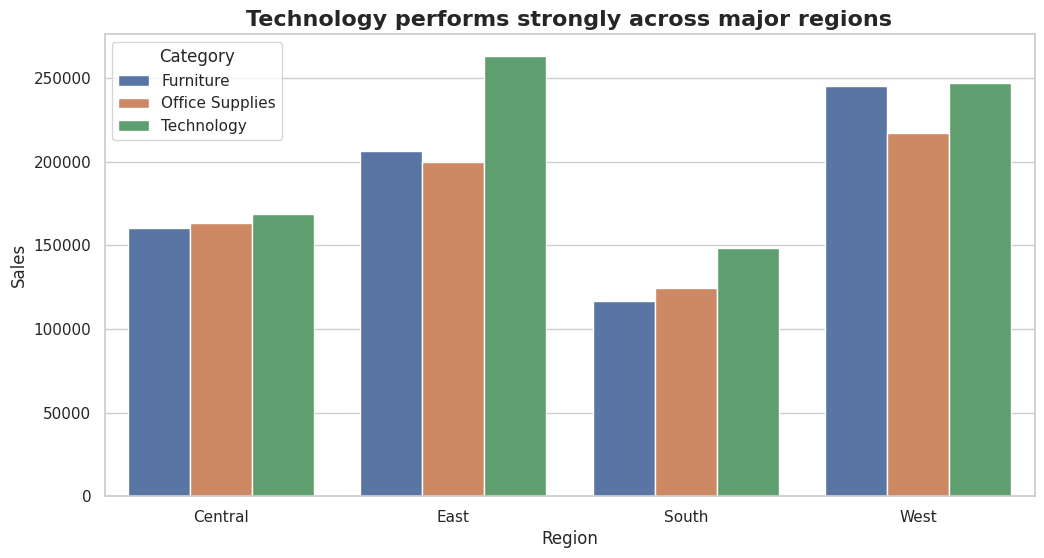

In [14]:
category_region = df.groupby(["Region", "Category"])["Sales"].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=category_region, x="Region", y="Sales", hue="Category")
plt.title("Technology performs strongly across major regions", fontsize=16, weight="bold")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

# **STEP 15: Ship Mode Analysis**

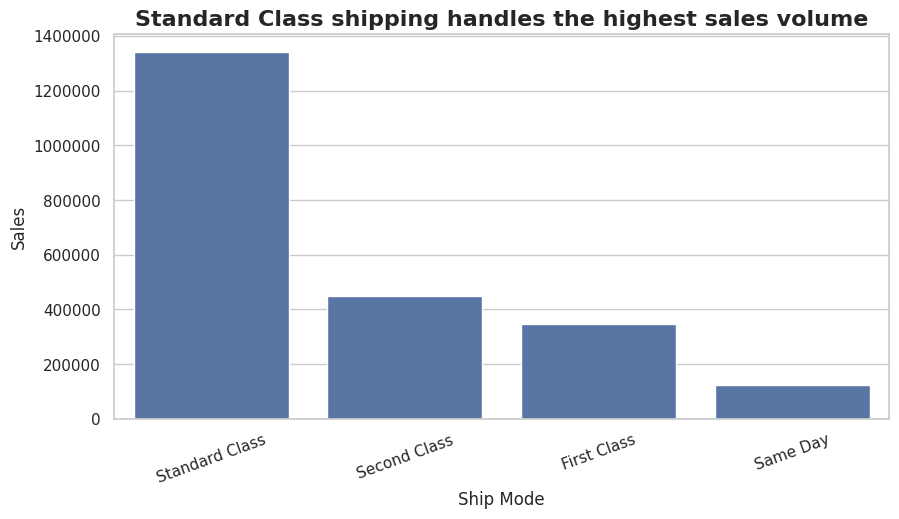

In [15]:
ship_sales = df.groupby("Ship Mode")["Sales"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=ship_sales, x="Ship Mode", y="Sales")
plt.title("Standard Class shipping handles the highest sales volume", fontsize=16, weight="bold")
plt.xlabel("Ship Mode")
plt.ylabel("Sales")
plt.xticks(rotation=20)
plt.ticklabel_format(style="plain", axis="y")
plt.show()

# **STEP 16: Sales Distribution**

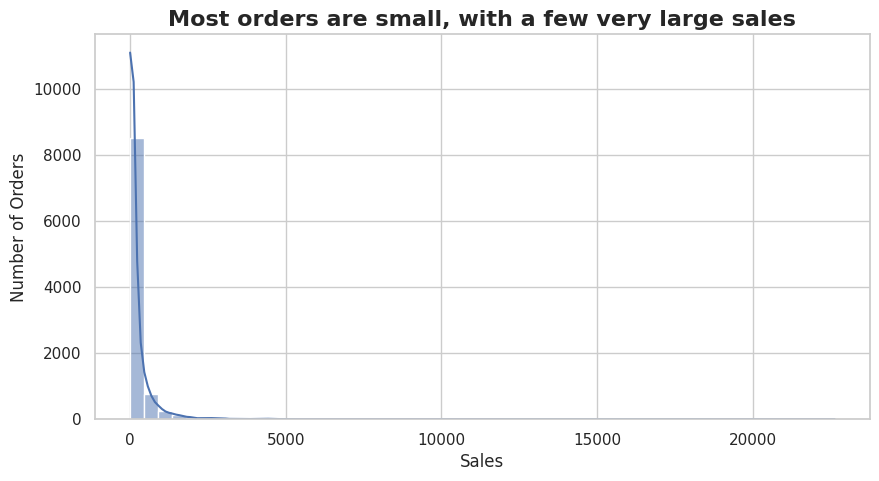

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Sales"], bins=50, kde=True)
plt.title("Most orders are small, with a few very large sales", fontsize=16, weight="bold")
plt.xlabel("Sales")
plt.ylabel("Number of Orders")
plt.show()

# **STEP 17: Correlation Heatmap**

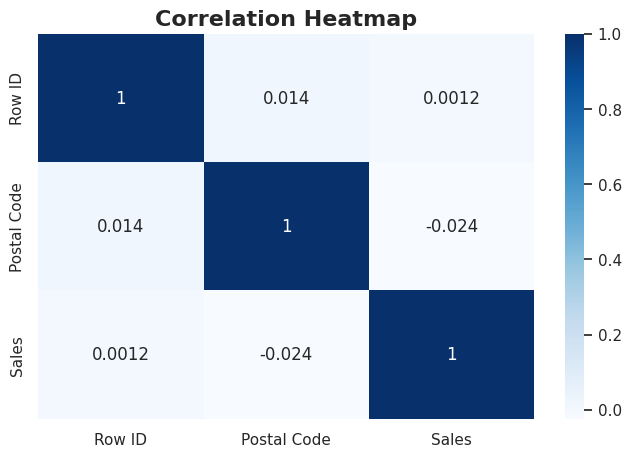

In [17]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap", fontsize=16, weight="bold")
plt.show()

# **STEP 18: Final Summary Table**

In [18]:
summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Best Category",
        "Best Region",
        "Best Segment"
    ],
    "Value": [
        round(total_sales, 2),
        total_orders,
        total_customers,
        round(avg_order_value, 2),
        category_sales.iloc[0]["Category"],
        region_sales.iloc[0]["Region"],
        segment_sales.iloc[0]["Segment"]
    ]
})

summary

,Metric,Value
0,Total Sales,2261536.78
1,Total Orders,4922
2,Total Customers,793
3,Average Order Value,459.48
4,Best Category,Technology
5,Best Region,West
6,Best Segment,Consumer


# **DATA STORYTELLING PROCESS FOR SUPERSTORE SALES PROJECT**

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# **STEP 1: LOAD DATA**

In [20]:
df = pd.read_csv("train.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Year-Month"] = df["Order Date"].dt.to_period("M").astype(str)

df = df.drop_duplicates()

# **STEP 2: CREATE BUSINESS KPIs**

In [21]:
total_sales = df["Sales"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
avg_order_value = total_sales / total_orders

print("BUSINESS SNAPSHOT")
print("-----------------")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value: ${avg_order_value:,.2f}")

BUSINESS SNAPSHOT
-----------------
Total Sales: $2,261,536.78
Total Orders: 4,922
Total Customers: 793
Average Order Value: $459.48


# **STEP 3: STORY PART 1 — SITUATION**

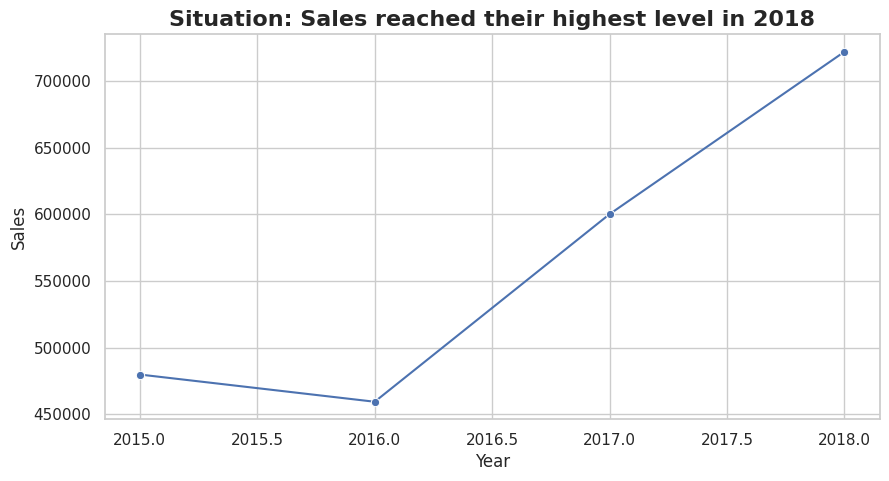

SITUATION
---------
The company generated sales across multiple years, categories, regions, and customer segments.
Sales increased strongly by 2018, showing clear business growth.


In [22]:
# What is happening overall?

yearly_sales = df.groupby("Year")["Sales"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_sales, x="Year", y="Sales", marker="o")
plt.title("Situation: Sales reached their highest level in 2018", fontsize=16, weight="bold")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

print("SITUATION")
print("---------")
print("The company generated sales across multiple years, categories, regions, and customer segments.")
print("Sales increased strongly by 2018, showing clear business growth.")

# **STEP 4: STORY PART 2 — COMPLICATION**

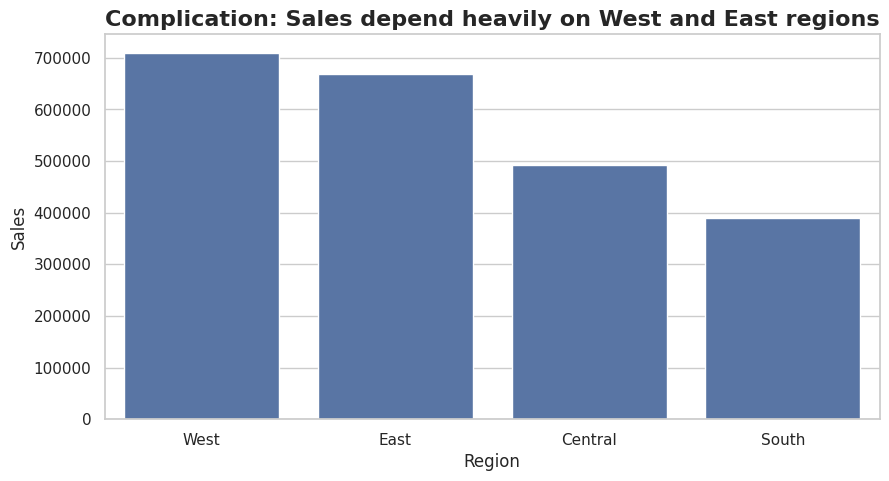

COMPLICATION
------------
Sales are not balanced across regions.
West and East are the strongest regions, while South generates the lowest sales.
This creates a business risk because growth depends heavily on a few strong regions.


In [23]:
# Where is performance uneven?

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=region_sales, x="Region", y="Sales")
plt.title("Complication: Sales depend heavily on West and East regions", fontsize=16, weight="bold")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

print("COMPLICATION")
print("------------")
print("Sales are not balanced across regions.")
print("West and East are the strongest regions, while South generates the lowest sales.")
print("This creates a business risk because growth depends heavily on a few strong regions.")

# **STEP 5: STORY PART 3 — PRODUCT INSIGHT**

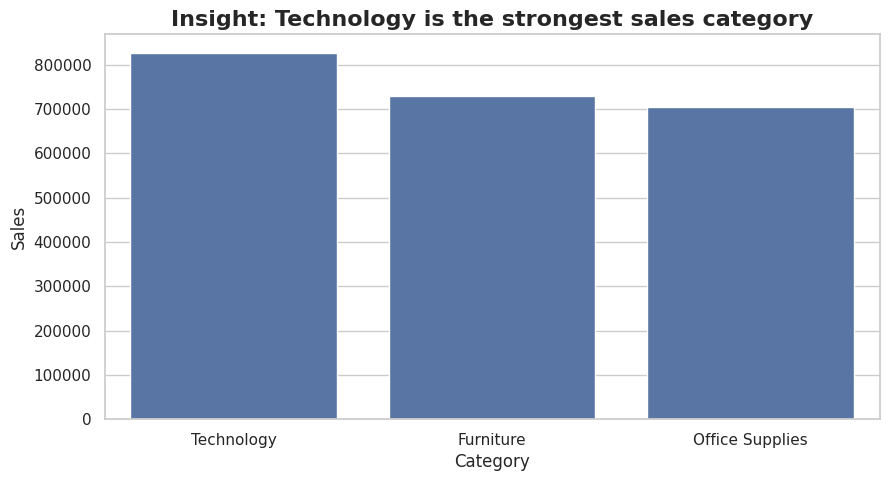

PRODUCT INSIGHT
---------------
Technology generates the highest sales.
This category should be protected and scaled because it is the strongest revenue driver.


In [24]:
# Which categories and products drive performance?

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=category_sales, x="Category", y="Sales")
plt.title("Insight: Technology is the strongest sales category", fontsize=16, weight="bold")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

print("PRODUCT INSIGHT")
print("---------------")
print("Technology generates the highest sales.")
print("This category should be protected and scaled because it is the strongest revenue driver.")

# **STEP 6: STORY PART 4 — SUB-CATEGORY INSIGHT**

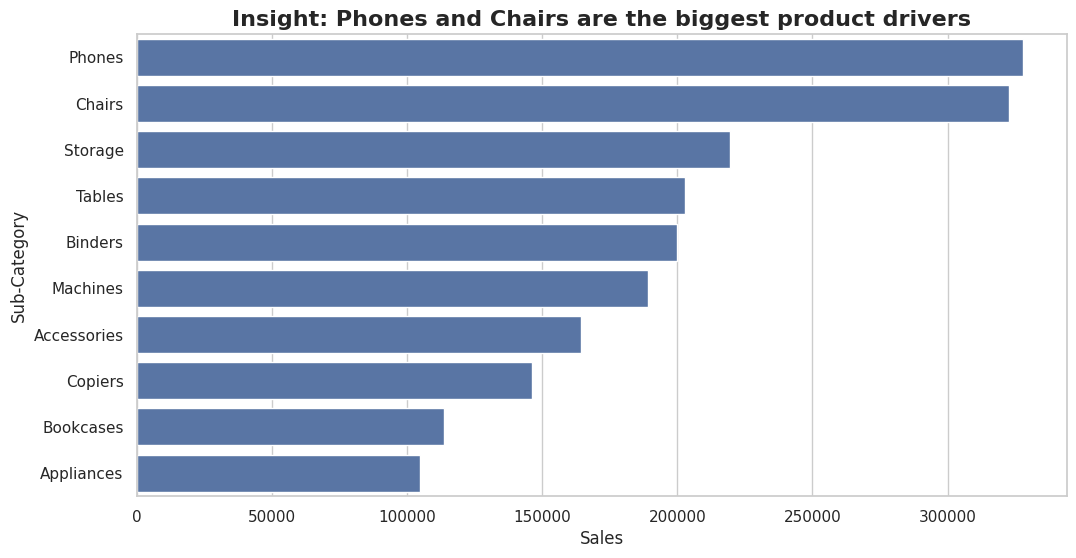

SUB-CATEGORY INSIGHT
--------------------
Phones and Chairs are the top sales-generating sub-categories.
These products should receive priority in inventory, marketing, and sales planning.


In [25]:
# Which products should management focus on?


subcat_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=subcat_sales, y="Sub-Category", x="Sales")
plt.title("Insight: Phones and Chairs are the biggest product drivers", fontsize=16, weight="bold")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

print("SUB-CATEGORY INSIGHT")
print("--------------------")
print("Phones and Chairs are the top sales-generating sub-categories.")
print("These products should receive priority in inventory, marketing, and sales planning.")

# **STEP 7: STORY PART 5 — CUSTOMER SEGMENT INSIGHT**

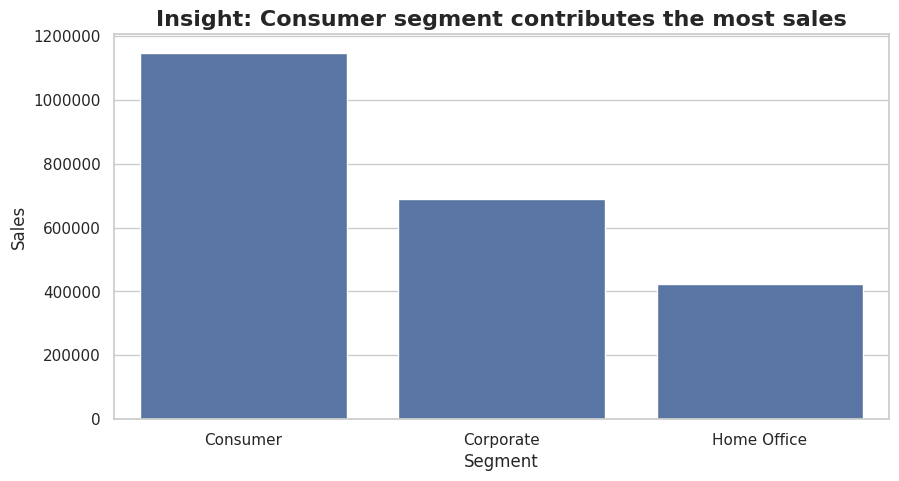

CUSTOMER INSIGHT
----------------
The Consumer segment contributes the highest sales.
The company should continue targeting consumer buyers while also improving Corporate and Home Office sales.


In [26]:
# Who is buying the most?

segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=segment_sales, x="Segment", y="Sales")
plt.title("Insight: Consumer segment contributes the most sales", fontsize=16, weight="bold")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

print("CUSTOMER INSIGHT")
print("----------------")
print("The Consumer segment contributes the highest sales.")
print("The company should continue targeting consumer buyers while also improving Corporate and Home Office sales.")

# **STEP 8: STORY PART 6 — RESOLUTION**

In [27]:
# What should the business do next?

print("RESOLUTION")
print("----------")
print("1. Focus on Technology because it is the strongest category.")
print("2. Protect high-performing products such as Phones and Chairs.")
print("3. Replicate West and East regional strategies in weaker regions.")
print("4. Investigate why South has lower sales.")
print("5. Target Consumer customers because they generate the highest sales.")

RESOLUTION
----------
1. Focus on Technology because it is the strongest category.
2. Protect high-performing products such as Phones and Chairs.
3. Replicate West and East regional strategies in weaker regions.
4. Investigate why South has lower sales.
5. Target Consumer customers because they generate the highest sales.


# **STEP 9: FINAL EXECUTIVE STORY**

In [28]:
# Boardroom-ready conclusion

best_year = yearly_sales.sort_values("Sales", ascending=False).iloc[0]
best_region = region_sales.iloc[0]
weakest_region = region_sales.iloc[-1]
best_category = category_sales.iloc[0]
best_segment = segment_sales.iloc[0]
best_subcategory = subcat_sales.iloc[0]

story = f"""
FINAL DATA STORY

Sales reached their highest level in {int(best_year['Year'])}, showing strong business growth.

However, the growth is not evenly distributed. The {best_region['Region']} region generates the highest sales,
while the {weakest_region['Region']} region contributes the lowest sales.

The strongest product category is {best_category['Category']}, and the top sub-category is {best_subcategory['Sub-Category']}.
The strongest customer segment is {best_segment['Segment']}.

Therefore, the company should focus on Technology products, protect top-performing sub-categories,
replicate successful regional strategies from strong regions, and improve weak regional performance.
"""

print(story)


FINAL DATA STORY

Sales reached their highest level in 2018, showing strong business growth.

However, the growth is not evenly distributed. The West region generates the highest sales,
while the South region contributes the lowest sales.

The strongest product category is Technology, and the top sub-category is Phones.
The strongest customer segment is Consumer.

Therefore, the company should focus on Technology products, protect top-performing sub-categories,
replicate successful regional strategies from strong regions, and improve weak regional performance.



# **STEP 10: CREATE STORYTELLING SUMMARY TABLE**

In [29]:
story_table = pd.DataFrame({
    "Story Stage": [
        "Situation",
        "Complication",
        "Insight 1",
        "Insight 2",
        "Insight 3",
        "Resolution"
    ],
    "Meaning": [
        "Sales increased and reached the highest level in 2018.",
        "Sales performance is uneven across regions.",
        "Technology is the strongest category.",
        "Phones and Chairs are the strongest sub-categories.",
        "Consumer segment generates the highest sales.",
        "Focus on strong products, improve weak regions, and scale successful strategies."
    ]
})

story_table

,Story Stage,Meaning
0,Situation,Sales increased and reached the highest level ...
1,Complication,Sales performance is uneven across regions.
2,Insight 1,Technology is the strongest category.
3,Insight 2,Phones and Chairs are the strongest sub-catego...
4,Insight 3,Consumer segment generates the highest sales.
5,Resolution,"Focus on strong products, improve weak regions..."


# **STEP 11: EXPORT STORY TABLE**

In [30]:
story_table.to_csv("data_storytelling_summary.csv", index=False)

print("Storytelling summary exported successfully.")

Storytelling summary exported successfully.


# **Results & Key Findings**

**Sales Growth:**

Sales showed consistent growth and reached their highest level in 2018, indicating strong business expansion.

**Top Category:**

Technology generated the highest sales among all product categories, making it the primary revenue driver.

**Best Performing Region:**

The West Region achieved the highest sales, followed closely by the East Region.

**Top Customer Segment:**

The Consumer Segment contributed the largest share of total revenue.

**Leading Products:**

Phones and Chairs were the highest-selling sub-categories and played a significant role in overall sales performance.

**Business Opportunity:**

The South Region generated comparatively lower sales, suggesting potential opportunities for targeted marketing and business improvement.

**The analysis reveals that the company's growth is primarily driven by Technology products, Consumer customers, and strong regional performance in the West and East. To sustain future growth, management should focus on expanding successful product categories, strengthening high-performing regions, and implementing improvement strategies in underperforming markets. This data-driven approach can help maximize revenue and support better business decisions**.